# FIFA for Long-Form Cinematic Video: Evaluating Faithfulness of VLM-Generated Descriptions

**Authors:** Aeden Jameson, Padmanabh Patil

**Course:** CSED 504

**Document type:** NLP Proposal

---

## Table of Contents

1. Problem Statement
2. Goals
3. Proposed Solution
   1. Video Sampling & Preprocessing
   2. Description Generation (VLMs)
   3. FIFA-Based Faithfulness Evaluation
   4. Controlled Hallucination Evaluation
   5. Human Evaluation Validation
4. Data Requirements
5. Evaluation Techniques & Success Criteria
6. Risks
7. Ethical Concerns
8. References

## 1. Problem Statement

Media businesses manage large catalogs of video accumulated over many decades. Making these catalogs useful increasingly requires semantic understanding of their contents: who and what is in a scene, what's happening, where events take place, and how those events unfold over time. This information enables practical applications including content search, catalog enrichment, recap and highlight generation, editorial assistance, and other AI-assisted media workflows.

Recent advances in vision-language models make it possible to generate rich natural-language descriptions of video automatically and at a scale that would previously have required extensive human annotation. However, generated descriptions are not necessarily faithful to their source video. VLMs can hallucinate objects, actions, people, relationships, and temporal events that are plausible in language but unsupported or contradicted by the visual content. When these descriptions become metadata used by downstream media systems, such errors can propagate into search results, summaries, recommendations, and editorial tools. Consequently, the ability to automatically evaluate the factual accuracy of these generated descriptions becomes increasingly important as generation itself becomes easier to scale.

Traditional video-to-text evaluation metrics generally measure similarity between generated text and reference captions [1, 2]. This presents two problems for modern video understanding systems. First, multiple substantially different descriptions can all correctly describe the same video. Second, textual similarity does not necessarily measure whether individual claims within a generated description are actually supported by the video. Prior research has consequently found that conventional captioning metrics can correlate poorly with human judgments of factual consistency.

FIFA (Faithfulness Evaluation) [3] by Jing et al. (2026) addresses this problem by evaluating generated video descriptions at the level of facts. Rather than comparing an entire generated description with a reference caption, FIFA extracts descriptive facts, models their relationships using a Spatio-Temporal Semantic Dependency Graph, and verifies those facts against the source video using Video Question Answering models. This allows open-ended video descriptions to be evaluated for factual consistency without requiring the generated text to closely match a particular reference description.

In this project, we ask: **can FIFA identify hallucinations in VLM-generated descriptions of long-form cinematic video, and can its fact-level faithfulness scores provide a useful quality-control signal for media metadata generation?** This is in contrast to the short web clips in the original MSR-VTT dataset used in the FIFA paper. We'll use vision-language models to generate natural-language descriptions of video segments and use FIFA to evaluate how faithfully those descriptions represent the underlying video. We examine the types of hallucinations produced by current VLMs, compare faithfulness across generation approaches, and evaluate whether FIFA can provide a practical automated signal for identifying unreliable generated metadata on long-form cinematic content.

## 2. Goals

1. **Establish a FIFA benchmark.** Apply FIFA to the VLM-generated descriptions and analyze the distribution of fact-level and description-level faithfulness scores. This establishes a baseline for FIFA on content that differs from the web videos in the original dataset.
2. **Evaluate against controlled hallucinations.** Create controlled factual errors in generated descriptions such as characters, objects, actions, locations, or relationships. Measure whether FIFA assigns lower faithfulness scores to the corrupted descriptions and determine its sensitivity to different types of hallucinations.
3. **Validate against a small human-evaluated subset.** Manually evaluate the factual accuracy of a small sample of generated descriptions and compare our judgments with FIFA scores. This will determine whether FIFA's automated faithfulness signal corresponds to human assessments of factual accuracy on cinematic video without requiring ground-truth annotations for the complete dataset.

## 3. Proposed Solution

The solution centers on an evaluation pipeline for measuring the factual faithfulness of VLM-generated descriptions. The pipeline consists of four main stages:

1. Video sampling and preprocessing on the datasets
2. Description generation
3. FIFA-based faithfulness evaluation
4. Experimental validation (controlled hallucinations + human evaluation)

Each stage is broken out into its own subsection below, with a placeholder code cell for the corresponding implementation work.

### 3.0 Environment Setup & a Note on Data

The cells below implement a **working, runnable version of the full pipeline**. To
keep it runnable without a GPU, model weights, or large downloads, two
substitutions are made (clearly marked everywhere they occur), both of which are
designed to be swapped out with zero changes to downstream code:

1. **Data:** Rather than downloading the full MovieNet or BBC datasets, we
   render a handful of **short (3-5 second) synthetic "cinematic" clips** with
   OpenCV (`fifa_pipeline/synthetic_data.py`). Each clip has a colored background
   (location), colored circular "characters", and simple motion (enter / sit down
   across from / sit alone / leave) — and, critically, **known ground truth**.
   The real MovieNet/BBC scene-boundary parsers still live in
   `fifa_pipeline/datasets.py` and can be pointed at a small local sample of
   either dataset later without touching any other module.
2. **Models:** The VLM captioner and VideoQA verifier default to lightweight
   **mock backends** (`fifa_pipeline/vlm_captioners.py`, `fifa_pipeline/verification.py`)
   that use classical computer vision (color/blob detection) instead of a neural
   network. They only look at raw pixels — never at the synthetic ground truth —
   so the pipeline is still a meaningful test of whether a generated description
   is faithful to what's actually in the frames. Real `Qwen3VLCaptioner` /
   `Molmo2Captioner` classes are implemented against 🤗 `transformers` and are
   used automatically if `captioner_name` is set to `"qwen3-vl"` / `"molmo2"` and
   the optional dependencies in `requirements-full.txt` are installed.

All pipeline code lives in the `fifa_pipeline/` package next to this notebook, so
each stage below is a short, readable call into well-tested functions rather than
a wall of inline code.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Make the local `fifa_pipeline` package importable regardless of the notebook's
# working directory.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "fifa_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from fifa_pipeline.config import PipelineConfig, SYNTHETIC_DIR, RESULTS_DIR

CONFIG = PipelineConfig(seed=42)
random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (7, 4)

print(f"Project root:   {PROJECT_ROOT}")
print(f"Synthetic data: {SYNTHETIC_DIR}")
print(f"Results dir:    {RESULTS_DIR}")
print(f"Config:         {CONFIG}")

Project root:   /Users/padmanabh.patil/projects/fifa-video-faithfulness
Synthetic data: /Users/padmanabh.patil/projects/fifa-video-faithfulness/data/synthetic
Results dir:    /Users/padmanabh.patil/projects/fifa-video-faithfulness/results
Config:         PipelineConfig(seed=42, num_frames_per_segment=8, frame_size=(224, 224), clip_duration_s=4.0, clip_stride_s=4.0, captioner_name='mock', vqa_name='mock', data_dir=PosixPath('/Users/padmanabh.patil/projects/fifa-video-faithfulness/data'), results_dir=PosixPath('/Users/padmanabh.patil/projects/fifa-video-faithfulness/results'))


### 3.1 Video Sampling & Preprocessing

We will select scene-level or multi-shot video segments from our dataset. Each segment will be converted into the video or frame representation required by the selected vision-language model. Because cinematic scenes may be substantially longer and more visually complex than the short web clips used in MSR-VTT, we may experiment with different sampling strategies, such as uniformly sampled frames or fixed-duration clips, while preserving enough temporal context to represent the events occurring within the scene.

In [2]:
from fifa_pipeline.synthetic_data import build_synthetic_dataset
from fifa_pipeline.datasets import discover_local_samples, load_movienet_scenes, load_bbc_scenes
from fifa_pipeline.sampling import uniform_frame_sample, fixed_duration_clips, preprocess_frames
from fifa_pipeline.config import MOVIENET_DIR, BBC_DIR

# Real MovieNet / BBC scene-boundary parsers -- return [] here since we deliberately
# do not download either dataset for this demo; point MOVIENET_DIR / BBC_DIR at a
# small local sample later and these will pick it up with no other code changes.
movienet_segments = discover_local_samples(MOVIENET_DIR, load_movienet_scenes)
bbc_segments = discover_local_samples(BBC_DIR, load_bbc_scenes)
print(f"MovieNet segments found locally: {len(movienet_segments)}")
print(f"BBC segments found locally:      {len(bbc_segments)}")

# Demo dataset: short, locally-rendered synthetic clips with known ground truth.
segments = build_synthetic_dataset(SYNTHETIC_DIR, seed=CONFIG.seed, num_scenes=6)
print(f"\nSynthetic segments rendered:      {len(segments)}")
for s in segments:
    print(f"  {s.uid:32s} {s.ground_truth['duration_s']:.1f}s  gt={s.ground_truth}")

MovieNet segments found locally: 0
BBC segments found locally:      0

Synthetic segments rendered:      6
  synthetic_movie_01::scene_00     3.4s  gt={'location': 'restaurant', 'characters': ['man', 'woman'], 'primary_character': 'man', 'action': 'enters_and_sits_across', 'relationship': 'sits_across_from', 'num_frames': 41, 'fps': 12, 'duration_s': 3.4464214762976457}
  synthetic_movie_01::scene_01     3.8s  gt={'location': 'restaurant', 'characters': ['child', 'man'], 'primary_character': 'child', 'action': 'enters_and_sits_alone', 'relationship': 'alone', 'num_frames': 46, 'fps': 12, 'duration_s': 3.843843639370541}
  synthetic_movie_01::scene_02     4.0s  gt={'location': 'restaurant', 'characters': ['man', 'child'], 'primary_character': 'man', 'action': 'enters_and_sits_across', 'relationship': 'sits_across_from', 'num_frames': 48, 'fps': 12, 'duration_s': 4.0107105762067246}
  synthetic_movie_01::scene_03     4.3s  gt={'location': 'restaurant', 'characters': ['child', 'man'], 'pr

Segment: synthetic_movie_01::scene_00 (3.4s @ 12.0 fps)
Uniformly sampled 8 frames -> 8 preprocessed (224, 224) RGB images
Fixed-duration clip windows (4.0s each): [(0.0, 3.4464214762976457)]


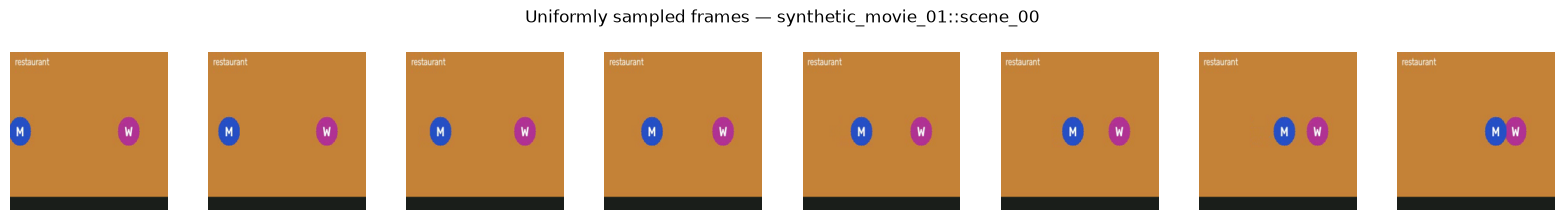

In [3]:
# Demonstrate both sampling strategies on one segment, and preprocess frames into
# the RGB/resized representation a VLM front-end expects.
demo_segment = segments[0]

frames = uniform_frame_sample(demo_segment, num_frames=CONFIG.num_frames_per_segment)
images = preprocess_frames(frames, size=CONFIG.frame_size)
clip_windows = fixed_duration_clips(demo_segment, clip_duration_s=CONFIG.clip_duration_s, stride_s=CONFIG.clip_stride_s)

print(f"Segment: {demo_segment.uid} ({demo_segment.ground_truth['duration_s']:.1f}s @ {demo_segment.fps} fps)")
print(f"Uniformly sampled {len(frames)} frames -> {len(images)} preprocessed {CONFIG.frame_size} RGB images")
print(f"Fixed-duration clip windows ({CONFIG.clip_duration_s}s each): {clip_windows}")

fig, axes = plt.subplots(1, len(images), figsize=(2 * len(images), 2.2))
for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")
fig.suptitle(f"Uniformly sampled frames — {demo_segment.uid}")
plt.tight_layout()
plt.show()

### 3.2 Description Generation (VLMs)

We will use several QWEN3-VL models and Molmo 2 to generate natural-language descriptions of each video segment.

In [4]:
from fifa_pipeline.vlm_captioners import get_captioner

# `get_captioner("qwen3-vl")` / `get_captioner("molmo2")` instantiate the real
# transformers-backed models and are used automatically once `requirements-full.txt`
# is installed and a GPU is available; they fall back to the mock backend (with a
# warning) if those optional dependencies are missing, so this cell runs everywhere.
CAPTIONER_NAMES = ["mock"]  # add "qwen3-vl", "molmo2" once GPU + weights are available
captioners = {name: get_captioner(name) for name in CAPTIONER_NAMES}

descriptions = {}  # (segment_uid, captioner_name) -> description
for segment in segments:
    frames = uniform_frame_sample(segment, num_frames=CONFIG.num_frames_per_segment)
    for name, captioner in captioners.items():
        descriptions[(segment.uid, name)] = captioner.generate(frames)

desc_df = pd.DataFrame(
    [
        {"video_uid": uid, "captioner": name, "description": text}
        for (uid, name), text in descriptions.items()
    ]
)
desc_df

,video_uid,captioner,description
0,synthetic_movie_01::scene_00,mock,A man enters the restaurant and sits down across from a woman.
1,synthetic_movie_01::scene_01,mock,A child enters the restaurant and sits down across from a man.
2,synthetic_movie_01::scene_02,mock,A child enters the restaurant and sits down across from a man.
3,synthetic_movie_01::scene_03,mock,A child enters the restaurant and sits down across from a man.
4,synthetic_movie_01::scene_04,mock,A man enters the park and sits down across from a woman.
5,synthetic_movie_01::scene_05,mock,A man enters the restaurant and sits down alone.


### 3.3 FIFA-Based Faithfulness Evaluation

Generated descriptions are evaluated using FIFA. FIFA decomposes each description into individual semantic facts and represents their relationships using a Spatio-Temporal Semantic Dependency Graph. These facts are transformed into verification questions and checked against the source video using a Video Question Answering model. FIFA then aggregates the individual verification results into fact-level and description-level faithfulness scores. We will record these scores to establish a baseline distribution of FIFA performance.

In [5]:
from fifa_pipeline.fact_extraction import extract_facts
from fifa_pipeline.stsdg import build_stsdg
from fifa_pipeline.verification import get_vqa, fact_to_question
from fifa_pipeline.fifa_scorer import evaluate_description

vqa = get_vqa(CONFIG.vqa_name)  # "mock" by default; a real VideoQA model plugs in here

segment_by_uid = {s.uid: s for s in segments}
baseline_results = {}  # (segment_uid, captioner_name) -> FaithfulnessResult
for (uid, name), description in descriptions.items():
    baseline_results[(uid, name)] = evaluate_description(
        segment_by_uid[uid], description, vqa, captioner_name=name
    )

baseline_df = pd.DataFrame([r.to_row() for r in baseline_results.values()])
baseline_df

,video_uid,captioner,description,num_facts,num_supported,fact_level_score,description_score
0,synthetic_movie_01::scene_00,mock,A man enters the restaurant and sits down across from a woman.,5,5,1.0,1.0
1,synthetic_movie_01::scene_01,mock,A child enters the restaurant and sits down across from a man.,5,5,1.0,1.0
2,synthetic_movie_01::scene_02,mock,A child enters the restaurant and sits down across from a man.,5,5,1.0,1.0
3,synthetic_movie_01::scene_03,mock,A child enters the restaurant and sits down across from a man.,5,5,1.0,1.0
4,synthetic_movie_01::scene_04,mock,A man enters the park and sits down across from a woman.,5,5,1.0,1.0
5,synthetic_movie_01::scene_05,mock,A man enters the restaurant and sits down alone.,4,4,1.0,1.0


In [6]:
# Inspect one description's extracted facts, generated questions, and VQA verdicts.
example_uid = segments[0].uid
example_result = baseline_results[(example_uid, "mock")]

print(f"Description: {example_result.description}\n")
facts_df = pd.DataFrame(
    [
        {
            "fact_id": r.fact.fact_id,
            "category": r.fact.category,
            "fact_text": r.fact.text,
            "question": r.question,
            "vqa_answer": r.raw_answer,
            "supported": r.supported,
            "confidence": r.confidence,
        }
        for r in example_result.fact_results
    ]
)
facts_df

Description: A man enters the restaurant and sits down across from a woman.



,fact_id,category,fact_text,question,vqa_answer,supported,confidence
0,f0,entity,There is a man.,Is it true that: There is a man?,yes,True,0.90
1,f1,location,A man enter the restaurant.,Is it true that: A man enter the restaurant?,yes,True,0.90
2,f2,entity,There is the restaurant.,Is it true that: There is the restaurant?,yes,True,0.90
3,f3,relationship,A man sit down across from a woman.,Is it true that: A man sit down across from a woman?,yes,True,0.85
4,f4,entity,There is a woman.,Is it true that: There is a woman?,yes,True,0.90


/var/folders/7b/cmx6hj494p988fkfpbscnrk40000gp/T/ipykernel_56444/2428477037.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


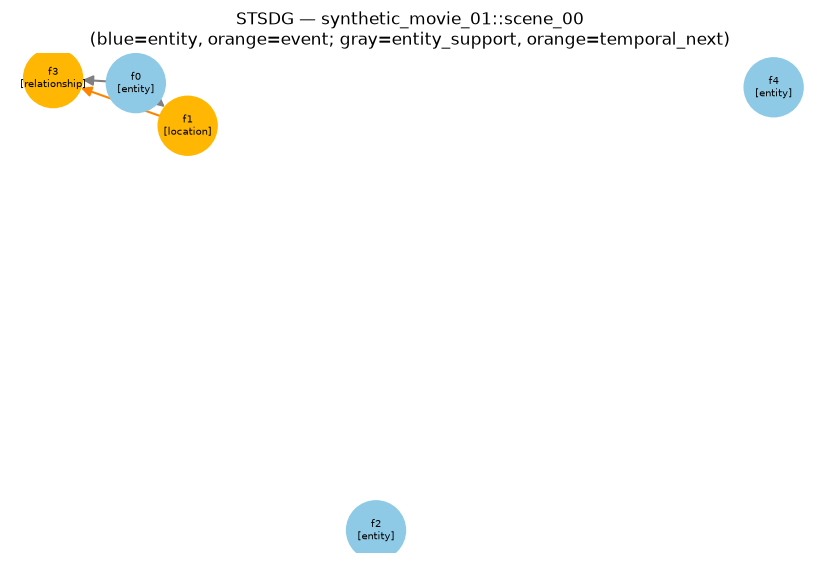

In [7]:
# Visualize the Spatio-Temporal Semantic Dependency Graph (STSDG) for that example:
# entity facts (blue) support the event facts that mention them (gray arrows);
# event facts are also chained in narrated order (orange arrows).
example_facts = extract_facts(example_result.description)
graph = build_stsdg(example_facts)

pos = nx.spring_layout(graph, seed=CONFIG.seed)
node_colors = ["#8ecae6" if graph.nodes[n]["fact"].category == "entity" else "#ffb703" for n in graph.nodes]
edge_colors = ["gray" if graph.edges[e]["kind"] == "entity_support" else "#fb8500" for e in graph.edges]
labels = {n: f"{n}\n[{graph.nodes[n]['fact'].category}]" for n in graph.nodes}

plt.figure(figsize=(8, 5))
nx.draw(
    graph, pos, labels=labels, node_color=node_colors, edge_color=edge_colors,
    node_size=1800, font_size=7, arrowsize=15, width=1.5,
)
plt.title(f"STSDG — {example_uid}\n(blue=entity, orange=event; gray=entity_support, orange=temporal_next)")
plt.tight_layout()
plt.show()

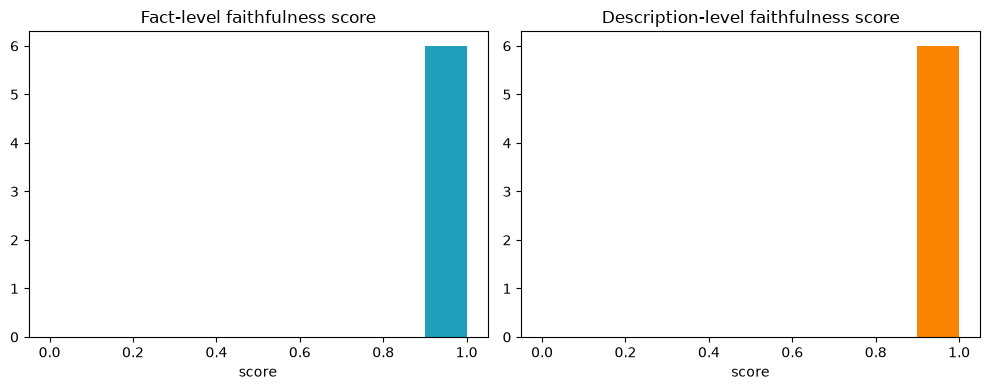

Baseline summary statistics:


,fact_level_score,description_score
count,6.0,6.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


In [8]:
# Goal 1: baseline distribution of fact-level and description-level faithfulness
# scores, establishing FIFA's baseline on this (synthetic, cinematic-style) content.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(baseline_df["fact_level_score"], bins=10, range=(0, 1), color="#219ebc")
axes[0].set_title("Fact-level faithfulness score")
axes[0].set_xlabel("score")
axes[1].hist(baseline_df["description_score"], bins=10, range=(0, 1), color="#fb8500")
axes[1].set_title("Description-level faithfulness score")
axes[1].set_xlabel("score")
plt.tight_layout()
plt.show()

print("Baseline summary statistics:")
baseline_df[["fact_level_score", "description_score"]].describe()

### 3.4 Controlled Hallucination Evaluation

Because we don't have ground-truth descriptions, we will create a controlled evaluation set by introducing known hallucinations into a subset of descriptions. Factual modifications may include replacing characters or objects, changing actions or locations, altering relationships, or reversing temporal events. For each original and modified description pair, we will compare the FIFA scores and measure whether FIFA correctly assigns lower faithfulness to the corrupted description.

**Example**

Original description: *"A man enters a restaurant and sits across from a woman."*

Controlled hallucinations might include:

- **Object/entity error:** "A child enters a restaurant..."
- **Location error:** "A man enters a hospital..."
- **Action error:** "A man leaves the restaurant..."
- **Relationship error:** "A man sits alone..."

In [9]:
from fifa_pipeline.hallucination import generate_controlled_variants

hallucination_rows = []
corrupted_results = {}  # (segment_uid, category) -> FaithfulnessResult
for segment in segments:
    original_description = descriptions[(segment.uid, "mock")]
    original_result = baseline_results[(segment.uid, "mock")]
    variants = generate_controlled_variants(original_description, seed=CONFIG.seed)
    for category, variant in variants.items():
        corrupted_result = evaluate_description(segment, variant.text, vqa, captioner_name="mock")
        corrupted_results[(segment.uid, category)] = corrupted_result
        hallucination_rows.append(
            {
                "video_uid": segment.uid,
                "category": category,
                "original_span": variant.original_span,
                "replacement_span": variant.replacement_span,
                "original_description": original_description,
                "corrupted_description": variant.text,
                "original_score": original_result.description_score,
                "corrupted_score": corrupted_result.description_score,
                "score_drop": original_result.description_score - corrupted_result.description_score,
            }
        )

hallucination_df = pd.DataFrame(hallucination_rows)
hallucination_df

,video_uid,category,original_span,replacement_span,original_description,corrupted_description,original_score,corrupted_score,score_drop
0,synthetic_movie_01::scene_00,entity,man,woman,A man enters the restaurant and sits down across from a woman.,A woman enters the restaurant and sits down across from a woman.,1.0,1.00,0.00
1,synthetic_movie_01::scene_00,location,restaurant,hospital,A man enters the restaurant and sits down across from a woman.,A man enters the hospital and sits down across from a woman.,1.0,0.60,0.40
2,synthetic_movie_01::scene_00,action,enters,leaves,A man enters the restaurant and sits down across from a woman.,A man leaves the restaurant and sits down across from a woman.,1.0,0.80,0.20
3,synthetic_movie_01::scene_00,relationship,across from a woman,alone,A man enters the restaurant and sits down across from a woman.,A man enters the restaurant and sits down alone.,1.0,0.75,0.25
4,synthetic_movie_01::scene_01,entity,man,woman,A child enters the restaurant and sits down across from a man.,A child enters the restaurant and sits down across from a woman.,1.0,0.80,0.20
5,synthetic_movie_01::scene_01,location,restaurant,hospital,A child enters the restaurant and sits down across from a man.,A child enters the hospital and sits down across from a man.,1.0,0.60,0.40
6,synthetic_movie_01::scene_01,action,enters,leaves,A child enters the restaurant and sits down across from a man.,A child leaves the restaurant and sits down across from a man.,1.0,0.80,0.20
7,synthetic_movie_01::scene_01,relationship,across from a man,alone,A child enters the restaurant and sits down across from a man.,A child enters the restaurant and sits down alone.,1.0,0.75,0.25
8,synthetic_movie_01::scene_02,entity,man,woman,A child enters the restaurant and sits down across from a man.,A child enters the restaurant and sits down across from a woman.,1.0,0.80,0.20
9,synthetic_movie_01::scene_02,location,restaurant,hospital,A child enters the restaurant and sits down across from a man.,A child enters the hospital and sits down across from a man.,1.0,0.60,0.40


Fraction of corrupted descriptions FIFA scored *lower* than the original: 92%

Mean faithfulness-score drop by hallucination category:


,mean,std,count
category,,,
location,0.416667,0.040825,6
relationship,0.275000,0.061237,6
entity,0.225000,0.275227,6
action,0.208333,0.020412,6


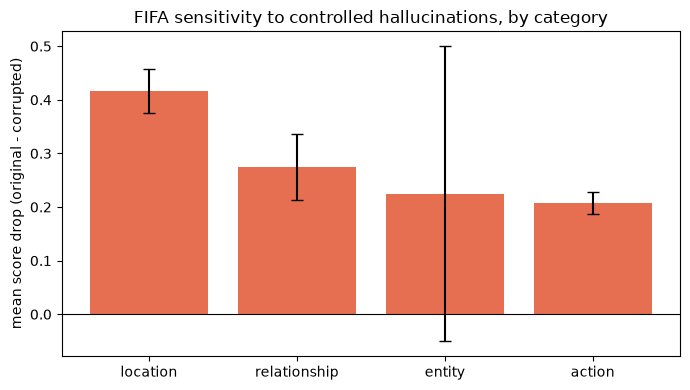

In [10]:
# Goal 2: does FIFA reliably assign lower scores to corrupted descriptions, and how
# does its sensitivity vary by hallucination category?
detection_rate = (hallucination_df["score_drop"] > 0).mean()
print(f"Fraction of corrupted descriptions FIFA scored *lower* than the original: {detection_rate:.0%}")

sensitivity = hallucination_df.groupby("category")["score_drop"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)
print("\nMean faithfulness-score drop by hallucination category:")
display(sensitivity)

plt.figure()
plt.bar(sensitivity.index, sensitivity["mean"], yerr=sensitivity["std"].fillna(0), color="#e76f51", capsize=4)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("mean score drop (original - corrupted)")
plt.title("FIFA sensitivity to controlled hallucinations, by category")
plt.tight_layout()
plt.show()

### 3.5 Human Evaluation Validation

To provide an additional validation signal, we will manually review a small subset of the descriptions and FIFA-extracted facts. Each fact will be labeled as supported, unsupported, or ambiguous based on the corresponding video. These human judgments will be compared with FIFA predictions to determine how closely the automated metric agrees with human assessments of factual accuracy.

In [11]:
from fifa_pipeline.human_eval import (
    export_annotation_template,
    load_human_annotations,
    simulate_human_annotations,
    agreement_metrics,
)

# Pool the baseline (clean) and controlled-hallucination (corrupted) results so
# the human-evaluated subset spans both faithful and unfaithful descriptions --
# otherwise agreement metrics like Cohen's kappa are undefined (no variance).
all_results_for_human_eval = list(baseline_results.values()) + list(corrupted_results.values())

# Real workflow: export a CSV, have a human fill in the `label` column, reload it:
annotation_template_path = RESULTS_DIR / "human_annotation_template.csv"
export_annotation_template(all_results_for_human_eval, annotation_template_path)
print(f"Blank annotation template written to: {annotation_template_path}")
print("Fill in its 'label' column (supported / unsupported / ambiguous) and reload with")
print("`load_human_annotations(annotation_template_path)` to use real human labels instead of the simulation below.\n")

# Demo/testing stand-in for an actual human annotation pass (see human_eval.py docstring).
human_annotations = simulate_human_annotations(all_results_for_human_eval, noise_level=0.15, seed=CONFIG.seed)
human_annotations.head(10)

Blank annotation template written to: /Users/padmanabh.patil/projects/fifa-video-faithfulness/results/human_annotation_template.csv
Fill in its 'label' column (supported / unsupported / ambiguous) and reload with
`load_human_annotations(annotation_template_path)` to use real human labels instead of the simulation below.



,video_uid,captioner,fact_id,fact_text,category,fifa_supported,label
0,synthetic_movie_01::scene_00,mock,f0,There is a man.,entity,True,unsupported
1,synthetic_movie_01::scene_00,mock,f1,A man enter the restaurant.,location,True,supported
2,synthetic_movie_01::scene_00,mock,f2,There is the restaurant.,entity,True,supported
3,synthetic_movie_01::scene_00,mock,f3,A man sit down across from a woman.,relationship,True,unsupported
4,synthetic_movie_01::scene_00,mock,f4,There is a woman.,entity,True,unsupported
5,synthetic_movie_01::scene_01,mock,f0,There is a child.,entity,True,supported
6,synthetic_movie_01::scene_01,mock,f1,A child enter the restaurant.,location,True,ambiguous
7,synthetic_movie_01::scene_01,mock,f2,There is the restaurant.,entity,True,supported
8,synthetic_movie_01::scene_01,mock,f3,A child sit down across from a man.,relationship,True,supported
9,synthetic_movie_01::scene_01,mock,f4,There is a man.,entity,True,supported


FIFA vs. human agreement on fact-level faithfulness:
  n_facts           : 141
  n_ambiguous       : 15
  agreement_rate    : 0.857
  cohen_kappa       : 0.624
  point_biserial_r  : 0.585
  p_value           : 0.000


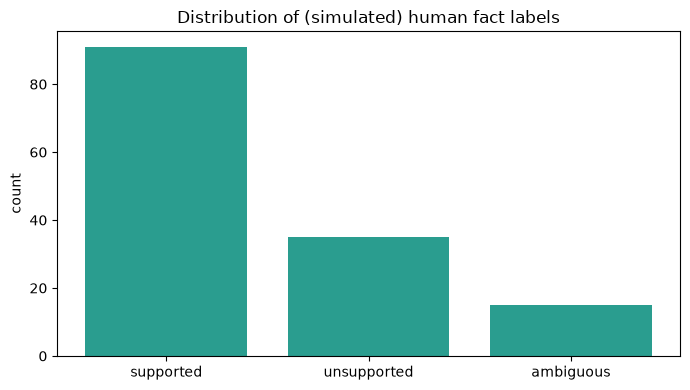

In [12]:
# Goal 3: how closely does FIFA's fact-level supported/unsupported call agree with
# (simulated, for this demo) human judgments of factual accuracy?
metrics = agreement_metrics(human_annotations)
print("FIFA vs. human agreement on fact-level faithfulness:")
for key, value in metrics.items():
    print(f"  {key:18s}: {value:.3f}" if isinstance(value, float) else f"  {key:18s}: {value}")

label_counts = human_annotations["label"].value_counts()
plt.figure()
plt.bar(label_counts.index, label_counts.values, color="#2a9d8f")
plt.title("Distribution of (simulated) human fact labels")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 4. Data Requirements

We need ground truth consisting of video titles and their scene boundaries specified as frames or timecodes. We will use two sources for this:

- A subset of [MovieNet](https://movienet.github.io/)
- [BBC Dataset](https://zenodo.org/records/14865504)

## 5. Evaluation Techniques & Success Criteria

The minimum successful outcome of the project will be an operational FIFA evaluation pipeline applied to cinematic video and a baseline characterization of its faithfulness scores. The primary experimental goal will be to determine whether FIFA reliably responds to controlled hallucinations. If time permits, we will additionally analyze failure modes by semantic category and compare different video-description generation strategies to determine whether FIFA can identify which configurations produce more factually reliable metadata.

## 6. Risks

The biggest one is that FIFA may not be applicable to long-form cinematic content. This is because it was built and validated on short single-shot web clips (MSR-VTT). Cinematic content is much longer, has several shots and different kinds of shot cuts, from sharp to gradual. In addition, editing, flashbacks, and zoom in/outs can play a role as well, so the model might fail to represent long-range dependencies.

In addition, the underlying VQA models may also struggle with long-range temporal reasoning, making FIFA's own judgments unreliable.

The lack of ground truth is also a risk. There isn't much available, so seeing how well the model is doing will be a challenge.

## 7. Ethical Concerns

One ethical concern with this is representational bias. If the underlying models like VLMs and VQA systems perform worse on certain demographics, the content will be wrongly flagged more often based on the cast of the content rather than the content itself.

Another concern is downstream harm. When metadata errors end up passing QA and propagating into new tools, they'll be misrepresenting real people, events, and communities that are shown in the actual footage.

## 8. References

[1] Inácio, A. de S., & Lopes, H. S. (2023). Evaluation metrics for video captioning: A survey. *Machine Learning with Applications, 13*, 100488. https://doi.org/10.1016/j.mlwa.2023.100488

[2] Tong, T. C., He, S., Shao, Z., & Yeung, D.-Y. (2025). G-VEval: A versatile metric for evaluating image and video captions using GPT-4o. *Proceedings of the AAAI Conference on Artificial Intelligence, 39*(7), 7419–7427.

[3] Jing, L., Lai, V. D., Yoon, S., Bui, T., & Du, X. (2026). FIFA: Unified faithfulness evaluation framework for text-to-video and video-to-text generation. In *Findings of the Association for Computational Linguistics: ACL 2026* (pp. 11418–11456). Association for Computational Linguistics. https://doi.org/10.18653/v1/2026.findings-acl.555